In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

# print("Path to dataset files:", path)

**Path to dataset files:** C:\Users\DELL\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1
**Link: ** https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import shutil
import random


In [3]:
# 1. Definisikan Path
dataset_path = "PetImages"
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')


In [4]:


# 2. Fungsi untuk membagi dataset (80% Train, 20% Test)
def split_data(base_path, categories, split_size=0.8):
    for category in categories:
        category_path = os.path.join(base_path, category)
        
        # Cek apakah folder kategori (Cat/Dog) ada
        if not os.path.exists(category_path) or category in ['train', 'test']:
            continue
            
        # Ambil daftar file dan acak
        files = [f for f in os.listdir(category_path) if os.path.getsize(os.path.join(category_path, f)) > 0]
        random.shuffle(files)
        
        # Tentukan titik pemisah
        train_count = int(len(files) * split_size)
        
        # Buat folder train dan test untuk kategori tersebut
        os.makedirs(os.path.join(train_dir, category), exist_ok=True)
        os.makedirs(os.path.join(test_dir, category), exist_ok=True)
        
        # Pindahkan file ke folder train
        for f in files[:train_count]:
            shutil.move(os.path.join(category_path, f), os.path.join(train_dir, category, f))
            
        # Pindahkan file sisanya ke folder test
        for f in files[train_count:]:
            shutil.move(os.path.join(category_path, f), os.path.join(test_dir, category, f))
        
        # Hapus folder asli yang sudah kosong
        os.rmdir(category_path)

# Eksekusi pembagian folder jika belum terbagi
if os.path.exists(os.path.join(dataset_path, "Cat")):
    split_data(dataset_path, ["Cat", "Dog"])
    print("Dataset berhasil dibagi menjadi train dan test.")

# 3. Data Augmentation dan Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=40, 
    width_shift_range=0.2, 
    height_shift_range=0.2, 
    shear_range=0.2, 
    zoom_range=0.2, 
    horizontal_flip=True, 
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# 4. Generator
train_generator = train_datagen.flow_from_directory(
    train_dir, 
    target_size=(224, 224), 
    batch_size=64, 
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, 
    target_size=(224, 224), 
    batch_size=64, 
    class_mode='binary'
)

Found 19998 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from PIL import Image

Image.MAX_IMAGE_PIXELS = None 

# 1. Membangun Model yang Lebih Dalam (Deep CNN)
model = Sequential([
    # Blok 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    # Blok 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    # Blok 3
    Conv2D(124, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    # Blok 4
    Conv2D(124, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    # Fully Connected Layer
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Naikkan dropout untuk mencegah overfitting karena model lebih dalam
    Dense(1, activation='sigmoid')
])

# 2. Turunkan Learning Rate ke Nilai Aman
# Learning rate 0.05 terlalu besar dan merusak proses training. Gunakan 0.0001 (1e-4).
opt = Adam(learning_rate=0.0004) 

# 3. Compile Model
model.compile(
    optimizer=opt, 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 4. Proses Training
try:
    history = model.fit(
        train_generator,
        epochs=15, # Jika grafik masih naik, Anda bisa naikkan ke 20-30 epochs
        validation_data=test_generator,
        verbose=1
    )
except Exception as e:
    print(f"\nTerjadi error saat training: {e}")


c:\ALAN\Alan\Kelas Machine Learning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
227/313 ━━━━━━━━━━━━━━━━━━━━ 7:48 5s/step - accuracy: 0.5910 - loss: 1.0503

c:\ALAN\Alan\Kelas Machine Learning\venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1657s 5s/step - accuracy: 0.6387 - loss: 0.7015 - val_accuracy: 0.5048 - val_loss: 1.0933
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1214s 4s/step - accuracy: 0.7121 - loss: 0.5662 - val_accuracy: 0.6958 - val_loss: 0.6018
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1312s 4s/step - accuracy: 0.7404 - loss: 0.5204 - val_accuracy: 0.7976 - val_loss: 0.4543
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1249s 4s/step - accuracy: 0.7770 - loss: 0.4792 - val_accuracy: 0.7770 - val_loss: 0.4763
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1379s 4s/step - accuracy: 0.7985 - loss: 0.4439 - val_accuracy: 0.8086 - val_loss: 0.4514
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1072s 3s/step - accuracy: 0.8245 - loss: 0.3931 - val_accuracy: 0.8322 - val_loss: 0.4037
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1057s 3s/step - accuracy: 0.8457 - loss: 0.3510 - val_accuracy: 0.7744 - val_loss: 0.5495
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1053s 3s/step - accuracy: 0.8612 - loss: 0.3198 - val_accurac

In [6]:
model.save('image_clasification.h5')

## use model
Tidak perlu dibuka

```
from tensorflow.keras.models import load_model

# Memuat model yang sudah disimpan
model = load_model('nama_model_kamu.h5')
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # 1. Load gambar dan ubah ukurannya menjadi 224x224
    img = image.load_img(img_path, target_size=(224, 224))
    
    # 2. Ubah gambar menjadi array angka
    img_array = image.img_to_array(img)
    
    # 3. Tambahkan dimensi batch (karena model expect input [batch_size, height, width, channels])
    img_array = np.expand_dims(img_array, axis=0)
    
    # 4. Normalisasi (penting! harus sama dengan saat training, biasanya dibagi 255)
    img_array = img_array / 255.0
    
    # 5. Prediksi
    prediction = model.predict(img_array)
    
    # Karena pakai aktivasi 'sigmoid', hasilnya berupa angka antara 0 sampai 1
    if prediction[0] > 0.5:
        print(f"Hasil: Kelas B (Skor: {prediction[0][0]:.2f})")
    else:
        print(f"Hasil: Kelas A (Skor: {prediction[0][0]:.2f})")

# Contoh penggunaan:
predict_image('path/ke/gambar_baru.jpg')
```

## Plot

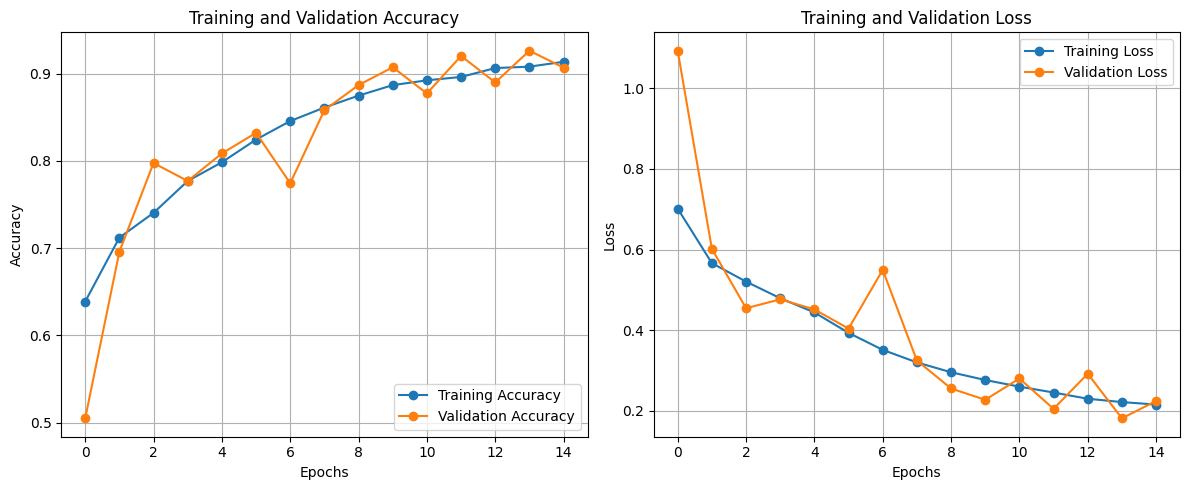

In [7]:
import matplotlib.pyplot as plt

# Ambil data dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Gunakan panjang data asli dari history (biar tidak error jika epochs berubah)
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5)) # Ukuran lebih proporsional untuk dua plot ke samping

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True) # Tambah grid agar lebih mudah dibaca

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout() # Mengatur jarak antar subplot agar tidak tumpang tindih
plt.show()
